<a href="https://colab.research.google.com/github/Nemosimes/NLP-Project/blob/MS2/ms2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [218]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [219]:
import zipfile, tarfile, os

archive_path = "/content/drive/MyDrive/Nlp/Project/ms2Data.zip"   # change to your filename

# For .zip
with zipfile.ZipFile(archive_path, 'r') as z:
    z.extractall("/content/dataset")

# For .tar.gz
# with tarfile.open(archive_path, 'r:gz') as t:
#     t.extractall("/content/dataset")

# See what's inside
for root, dirs, files in os.walk("/content/dataset"):
    for f in files:
        print(os.path.join(root, f))

/content/dataset/citizen_kane_test_set.json
/content/dataset/physics_movement_qa_dataset.json
/content/dataset/f35_test_set.json
/content/dataset/samurai_test_set.json
/content/dataset/samurai_qa_dataset.json
/content/dataset/taj_mahal_qa_dataset.json
/content/dataset/russia_empire_test_set.json
/content/dataset/citizen_kane_qa_dataset.json
/content/dataset/f35_qa_dataset.json
/content/dataset/octopus_qa_dataset.json
/content/dataset/taj_mahal_test_set.json
/content/dataset/octopus_test_set.json
/content/dataset/physics_movement_test_set.json
/content/dataset/russia_empire_qa_dataset.json


In [220]:
import glob
import json
import os

# Define your directory (use '.' for the main content folder or your Drive path)
path_to_json = "/content/dataset"
json_pattern = os.path.join(path_to_json, '*.json')
file_list = glob.glob(json_pattern)

data = []

for file in file_list:
    with open(file, 'r') as f:
        # Load each file and append to our list
        data.append(json.load(f))

print(f"Loaded {len(data)} files.")



Loaded 14 files.


In [221]:
import json, os, glob
import pandas as pd

# Set the path where your extracted files are
data_dir = "/content/dataset"  # adjust if needed

train_data = []
test_data  = []

for fpath in glob.glob(os.path.join(data_dir, "*.json")):
    fname = os.path.basename(fpath)
    with open(fpath, "r", encoding="utf-8") as f:
        records = json.load(f)  # list of {question, context, answer}

    if "test" in fname.lower():
        test_data.extend(records["data"])
    else:
        train_data.extend(records["data"])


print(f"Train samples: {len(train_data)}")
print(f"Test  samples: {len(test_data)}")
print("Sample:", train_data[0])

Train samples: 7
Test  samples: 7
Sample: {'title': 'physics_movement_training_final', 'paragraphs': [{'context': 'الفلاسفة الطبيعيون الأوائل مثل طاليس وأنكسيمناس وهيرقليطس اختلفوا حول أصل الكون. لكن رغم اختلافهم، كانت هناك فكرة مشتركة بينهم. كل مادة من دول بتتحرك وبتتحول طول الوقت، سواء كانت ماء أو هواء أو نار.', 'qas': [{'id': 'Q1', 'question': 'ما الفكرة المشتركة بين الفلاسفة الطبيعيين الأوائل حول الكون؟', 'answers': [{'text': 'كل مادة من دول بتتحرك وبتتحول طول الوقت'}]}]}, {'context': 'هيرقليطس كان يرى أن النار تمثل التغير المستمر. اختارها لأنها دائمًا في حالة حركة وتحول. بسبب حركتها المجنونة والمستمرة، اعتبرها أفضل تعبير عن طبيعة الكون.', 'qas': [{'id': 'Q2', 'question': 'لماذا اختار هيرقليطس النار كأصل للعالم؟', 'answers': [{'text': 'بسبب حركتها المجنونة والمستمرة'}]}]}, {'context': 'رغم اختلاف الفلاسفة، إلا أنهم اتفقوا على فكرة أساسية. كانوا شايفين إن الحركة هي عصب الوجود بالكامل. كل شيء في الكون في حالة تغير مستمر.', 'qas': [{'id': 'Q3', 'question': 'ماذا كان رأي الفلاسفة حول أ

In [222]:
def flatten(data):
    rows = []

    for item in data:
        title = item["title"]

        for para in item["paragraphs"]:
            context = para["context"]

            for qa in para["qas"]:
                question = qa["question"]
                answer = qa["answers"][0]["text"] if qa["answers"] else None

                rows.append({
                    "title": title,
                    "context": context,
                    "question": question,
                    "answer": answer
                })

    return rows

train_df = pd.DataFrame(flatten(train_data))
test_df = pd.DataFrame(flatten(test_data))

In [223]:

# Verify columns
#print(train_df.columns)
train_df.head()

,title,context,question,answer
0,physics_movement_training_final,الفلاسفة الطبيعيون الأوائل مثل طاليس وأنكسيمنا...,ما الفكرة المشتركة بين الفلاسفة الطبيعيين الأو...,كل مادة من دول بتتحرك وبتتحول طول الوقت
1,physics_movement_training_final,هيرقليطس كان يرى أن النار تمثل التغير المستمر....,لماذا اختار هيرقليطس النار كأصل للعالم؟,بسبب حركتها المجنونة والمستمرة
2,physics_movement_training_final,رغم اختلاف الفلاسفة، إلا أنهم اتفقوا على فكرة ...,ماذا كان رأي الفلاسفة حول أهمية الحركة؟,الحركة هي عصب الوجود بالكامل
3,physics_movement_training_final,مع ازدياد نفوذ الساموراي، بدأ احترام الناس لهم...,لماذا أصبح الناس يخافون من الساموراي؟,امتلاك السلاح وفرض النظام بالقوة
4,physics_movement_training_final,عالم الأعصاب دانيال وولبرت قدم تفسيرًا مختلفًا...,ماذا يقول عالم الأعصاب دانيال وولبرت عن وظيفة ...,وهي إنتاج سلسلة من الحركات المعقدة


In [224]:
import re

def contains_english(text):
    return bool(re.search(r"[A-Za-z]", str(text)))


cols = ["context", "question", "answer"]

english_rows = train_df[
   train_df[cols].apply(lambda row: any(contains_english(x) for x in row), axis=1)
]

print("Rows with English words:", len(english_rows))
english_rows.head()

Rows with English words: 26


,title,context,question,answer
44,samurai_training_final,طقس سيبوكو هو أن الساموراي بيلبس كيمونو أبيض و...,ما هو طقس Seppuku؟,الساموراي بيلبس كيمونو أبيض ويقوم غارز السيف ف...
66,taj_mahal_video,استخدموا تقنية اسمها Pietra Dura... التطعيم ال...,ما التقنية المستخدمة في زخرفة تاج محل بالأحجار...,Pietra Dura
78,citizen_kane_training_set,في تلك الفترة، اعتمدت أفلام هوليوود على قوالب ...,ما طبيعة أفلام هوليوود قبل Citizen Kane؟,قوالب تقليدية ونهايات سعيدة
85,citizen_kane_training_set,ينطق كين كلمة Rosebud قبل موته. تصبح هذه الكلم...,ما دور كلمة Rosebud؟,لغز لفهم شخصية كين
88,citizen_kane_training_set,تقنية Deep Focus تُظهر جميع عناصر المشهد بوضوح...,ما هي تقنية Deep Focus؟,إظهار جميع العناصر بوضوح


In [225]:
english_rows["english_count"] = train_df.apply(
    lambda row: sum(len(re.findall(r"[A-Za-z]+", str(row[c]))) for c in ["context","question","answer"]),
    axis=1
)

english_rows["english_count"].describe()

/tmp/ipykernel_20541/4000429766.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  english_rows["english_count"] = train_df.apply(


,english_count
count,26.000000
mean,2.423077
std,1.447013
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,8.000000


Dataset contains named entities and scientific English words which were preserved to maintain semantic meaning

In [226]:
import re

def preprocess(text):
    if not isinstance(text, str):
        text = str(text)

    # Remove punctuation & extra spaces
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    #  separate Arabic and English when glued
    text = re.sub(r"([\u0600-\u06FF])([A-Za-z])", r"\1 \2", text)
    text = re.sub(r"([A-Za-z])([\u0600-\u06FF])", r"\1 \2", text)

    # Remove punctuation (Arabic + English)
    # text = re.sub(r"[^\w\s\u0600-\u06FF]", " ", text)
    # remove punctuation better
    text = re.sub(r"[^\w\s\u0600-\u06FF<>]", " ", text)
    return text

# Concatenate question + context as model input
train_df["input"] = train_df["question"].apply(preprocess) + " [SEP] " + train_df["context"].apply(preprocess)
test_df["input"]  = test_df["question"].apply(preprocess)  + " [SEP] " + test_df["context"].apply(preprocess)

train_df["answer"] = train_df["answer"].apply(preprocess)
test_df["answer"]  = test_df["answer"].apply(preprocess)

In [227]:
train_df.head()


,title,context,question,answer,input
0,physics_movement_training_final,الفلاسفة الطبيعيون الأوائل مثل طاليس وأنكسيمنا...,ما الفكرة المشتركة بين الفلاسفة الطبيعيين الأو...,كل مادة من دول بتتحرك وبتتحول طول الوقت,ما الفكرة المشتركة بين الفلاسفة الطبيعيين الأو...
1,physics_movement_training_final,هيرقليطس كان يرى أن النار تمثل التغير المستمر....,لماذا اختار هيرقليطس النار كأصل للعالم؟,بسبب حركتها المجنونة والمستمرة,لماذا اختار هيرقليطس النار كأصل للعالم [SEP] ه...
2,physics_movement_training_final,رغم اختلاف الفلاسفة، إلا أنهم اتفقوا على فكرة ...,ماذا كان رأي الفلاسفة حول أهمية الحركة؟,الحركة هي عصب الوجود بالكامل,ماذا كان رأي الفلاسفة حول أهمية الحركة [SEP] ر...
3,physics_movement_training_final,مع ازدياد نفوذ الساموراي، بدأ احترام الناس لهم...,لماذا أصبح الناس يخافون من الساموراي؟,امتلاك السلاح وفرض النظام بالقوة,لماذا أصبح الناس يخافون من الساموراي [SEP] مع ...
4,physics_movement_training_final,عالم الأعصاب دانيال وولبرت قدم تفسيرًا مختلفًا...,ماذا يقول عالم الأعصاب دانيال وولبرت عن وظيفة ...,وهي إنتاج سلسلة من الحركات المعقدة,ماذا يقول عالم الأعصاب دانيال وولبرت عن وظيفة ...


In [228]:
train_df["input_len"] = train_df["input"].apply(lambda x: len(x.split()))

print(train_df["input_len"].describe())
print(f"Max  : {train_df['input_len'].max()}")
print(f"Mean : {train_df['input_len'].mean():.1f}")
print(f"95th percentile: {train_df['input_len'].quantile(0.95):.0f}")


count    168.000000
mean      20.976190
std        8.114416
min        7.000000
25%       15.000000
50%       18.500000
75%       26.000000
max       56.000000
Name: input_len, dtype: float64
Max  : 56
Mean : 21.0
95th percentile: 34


In [229]:
train_df["answer_len"] = train_df["answer"].apply(lambda x: len(preprocess(x).split()))

print(train_df["answer_len"].describe())
print(f"Max    : {train_df['answer_len'].max()}")
print(f"Mean   : {train_df['answer_len'].mean():.1f}")
print(f"Longest answer: {train_df.loc[train_df['answer_len'].idxmax(), 'answer']}")

count    168.000000
mean       4.892857
std        2.485974
min        1.000000
25%        3.000000
50%        5.000000
75%        7.000000
max       13.000000
Name: answer_len, dtype: float64
Max    : 13
Mean   : 4.9
Longest answer: أن السبب قد يكون كوني ا مثل فيروسات أو مواد جاءت من الفضاء


In [230]:
from collections import Counter

# Build vocab from training data only
all_text = " ".join(train_df["input"].tolist() + train_df["answer"].tolist())
tokens   = all_text.split()

print (tokens)

['ما', 'الفكرة', 'المشتركة', 'بين', 'الفلاسفة', 'الطبيعيين', 'الأوائل', 'حول', 'الكون', '[SEP]', 'الفلاسفة', 'الطبيعيون', 'الأوائل', 'مثل', 'طاليس', 'وأنكسيمناس', 'وهيرقليطس', 'اختلفوا', 'حول', 'أصل', 'الكون', 'لكن', 'رغم', 'اختلافهم', 'كانت', 'هناك', 'فكرة', 'مشتركة', 'بينهم', 'كل', 'مادة', 'من', 'دول', 'بتتحرك', 'وبتتحول', 'طول', 'الوقت', 'سواء', 'كانت', 'ماء', 'أو', 'هواء', 'أو', 'نار', 'لماذا', 'اختار', 'هيرقليطس', 'النار', 'كأصل', 'للعالم', '[SEP]', 'هيرقليطس', 'كان', 'يرى', 'أن', 'النار', 'تمثل', 'التغير', 'المستمر', 'اختارها', 'لأنها', 'دائم', 'ا', 'في', 'حالة', 'حركة', 'وتحول', 'بسبب', 'حركتها', 'المجنونة', 'والمستمرة', 'اعتبرها', 'أفضل', 'تعبير', 'عن', 'طبيعة', 'الكون', 'ماذا', 'كان', 'رأي', 'الفلاسفة', 'حول', 'أهمية', 'الحركة', '[SEP]', 'رغم', 'اختلاف', 'الفلاسفة', 'إلا', 'أنهم', 'اتفقوا', 'على', 'فكرة', 'أساسية', 'كانوا', 'شايفين', 'إن', 'الحركة', 'هي', 'عصب', 'الوجود', 'بالكامل', 'كل', 'شيء', 'في', 'الكون', 'في', 'حالة', 'تغير', 'مستمر', 'لماذا', 'أصبح', 'الناس', 'يخافون', 

In [231]:
english_tokens = []
for token in tokens:
    if contains_english(token) and token != "[SEP]":
        english_tokens.append(token)

print(f"Found {len(english_tokens)} English words/tokens in the vocabulary.")
print("Sample English tokens:", english_tokens)


Found 63 English words/tokens in the vocabulary.
Sample English tokens: ['Seppuku', 'Pietra', 'Dura', 'Citizen', 'Kane', 'Rosebud', 'Rosebud', 'Deep', 'Focus', 'Deep', 'Focus', 'Rosebud', 'Rosebud', 'F', 'Hangar', 'Hangar', 'Test', 'F', 'F', 'F', 'F', 'RAM', 'RCS', 'Radar', 'Cross', 'Section', 'F', 'F', 'F', 'F', 'F', 'Command', 'of', 'the', 'Air', 'Software', 'Software', 'Cephalopoda', 'Cephalo', 'Poda', 'Mantle', 'The', 'European', 'Plain', 'Attack', 'as', 'Defense', 'access', 'Streltsy', 'Play', 'Troops', 'Play', 'Troops', 'Pietra', 'Dura', 'F', 'Hangar', 'RAM', 'Command', 'of', 'the', 'Air', 'Mantle']


In [232]:
vocab    = Counter(tokens)
VOCAB_SIZE_LIMIT = 1000

word2idx = {"<PAD>": 0, "<UNK>": 1, "<SOS>": 2, "<EOS>": 3}
for word, count in vocab.most_common(VOCAB_SIZE_LIMIT):
    if count >= 2:  # only words that appear at least twice
        word2idx[word] = len(word2idx)

idx2word = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)
print(f"Vocabulary size: {VOCAB_SIZE}")
print (word2idx)
print (idx2word)

Vocabulary size: 847
{'<PAD>': 0, '<UNK>': 1, '<SOS>': 2, '<EOS>': 3, '[SEP]': 4, 'في': 5, 'ما': 6, 'من': 7, 'ا': 8, 'على': 9, 'إلى': 10, 'الساموراي': 11, 'لماذا': 12, 'الذي': 13, 'محل': 14, 'أن': 15, 'هو': 16, 'الحركة': 17, 'كيف': 18, 'الأخطبوط': 19, 'كانت': 20, 'كان': 21, 'عن': 22, 'ماذا': 23, 'اللي': 24, 'كل': 25, 'روسيا': 26, 'سنة': 27, 'تاج': 28, 'أو': 29, 'التي': 30, 'لا': 31, 'غير': 32, 'الأساسية': 33, 'لم': 34, 'جهان': 35, 'F': 36, '35': 37, 'بين': 38, 'إن': 39, 'زينون': 40, 'بعد': 41, 'الضوء': 42, 'شاه': 43, 'ويلز': 44, 'أول': 45, 'هذه': 46, 'الجسم': 47, 'عشان': 48, 'كين': 49, 'الطائرة': 50, 'حول': 51, 'الكون': 52, 'سبب': 53, 'هذا': 54, 'حوالي': 55, 'الـ': 56, 'الطيارة': 57, 'مثل': 58, 'بسبب': 59, 'كانوا': 60, 'مع': 61, 'مجرد': 62, 'مما': 63, 'تجربة': 64, 'قبل': 65, 'أي': 66, 'الإمبراطور': 67, 'اسم': 68, 'كم': 69, 'عدد': 70, 'تحت': 71, 'الفيلم': 72, 'الفكرة': 73, 'حركة': 74, 'الناس': 75, 'نفس': 76, 'اللحظة': 77, 'سرعة': 78, 'ممكن': 79, 'طاقة': 80, 'فيه': 81, 'تم': 82, 'اليابان

In [233]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

MAX_INPUT_LEN  = 64

# Check what longest answer is
max_ans = train_df["answer_len"].max()
print(f"Longest answer: {max_ans} words")

# Then set both to match
MAX_TARGET_LEN = max_ans + 2   # +2 for SOS and EOS

def encode_target(text, max_len=MAX_TARGET_LEN):
    tokens = preprocess(text).split()[:max_len - 2]
    ids  = [word2idx["<SOS>"]]
    ids += [word2idx.get(t, 1) for t in tokens]
    ids.append(word2idx["<EOS>"])
    return ids

def encode(text, max_len):
    tokens = text.split()[:max_len]
    return [word2idx.get(t, 1) for t in tokens]  # 1 = <UNK>


# Rebuild dataset with this
class QADataset(Dataset):
    def __init__(self, df):
        self.inputs  = [encode(row["input"], MAX_INPUT_LEN)
                        for _, row in df.iterrows()]
        self.targets = [encode_target(row["answer"])   # ← short + EOS
                        for _, row in df.iterrows()]

    def __len__(self): return len(self.inputs)

    def __getitem__(self, idx):
        return (torch.tensor(self.inputs[idx],  dtype=torch.long),
                torch.tensor(self.targets[idx], dtype=torch.long))

def collate_fn(batch):
    inputs, targets = zip(*batch)  #zip(*batch) unpacks this into two separate tuples: all inputs together, all targets together.
    inputs  = pad_sequence(inputs,  batch_first=True, padding_value=0)
    targets = pad_sequence(targets, batch_first=True, padding_value=0)
    return inputs, targets


Longest answer: 13 words


Model

In [234]:
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, n_layers,
                           batch_first=True, dropout=dropout, bidirectional=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        outputs, (hidden, cell) = self.rnn(embedded)
        return hidden, cell


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, n_layers,
                           batch_first=True, dropout=dropout)
        self.fc  = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden, cell):
        x        = x.unsqueeze(1)                         # (batch, 1)
        embedded = self.dropout(self.embedding(x))         # (batch, 1, embed)
        out, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        pred = self.fc(out.squeeze(1))                     # (batch, vocab_size)
        return pred, hidden, cell


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size  = src.shape[0]
        trg_len     = trg.shape[1]
        vocab_size  = self.decoder.fc.out_features

        outputs = torch.zeros(batch_size, trg_len, vocab_size).to(self.device)
        hidden, cell = self.encoder(src)

        dec_input = trg[:, 0]  # <SOS>
        for t in range(1, trg_len):
            out, hidden, cell = self.decoder(dec_input, hidden, cell)
            outputs[:, t, :] = out
            teacher_force = torch.rand(1).item() < teacher_forcing_ratio
            dec_input = trg[:, t] if teacher_force else out.argmax(1)

        return outputs

In [235]:
print(f"Train samples: {len(train_df)}")
print(f"Test  samples: {len(test_df)}")

Train samples: 168
Test  samples: 72


In [236]:
def predict_answer(model, question, context, max_len=8):
    model.eval()
    inp = preprocess(question) + " SEP " + preprocess(context)
    enc = encode(inp, MAX_INPUT_LEN)
    src = torch.tensor(enc, dtype=torch.long).unsqueeze(0).to(DEVICE)

    allowed_tokens = set(enc)
    allowed_tokens.discard(word2idx["<PAD>"])
    allowed_tokens.discard(word2idx["<SOS>"])
    allowed_tokens.discard(word2idx.get("<UNK>", 1))

    with torch.no_grad():
        hidden, cell = model.encoder(src)      # ← use model, not model1

    dec_input = torch.tensor([word2idx["<SOS>"]], dtype=torch.long).to(DEVICE)
    answer_tokens = []
    seen = set()

    for step in range(max_len):
        with torch.no_grad():
            out, hidden, cell = model.decoder(dec_input, hidden, cell)  # ← model

        mask = torch.full(out.shape, -float('inf')).to(DEVICE)
        for idx in allowed_tokens:
            mask[0][idx] = out[0][idx]
        if step == 0:
            mask[0][word2idx["<EOS>"]] = -float('inf')
        for idx in seen:
            mask[0][idx] = -float('inf')

        top_token = mask.argmax(1).item()
        if top_token == word2idx["<EOS>"]:
            break

        word = idx2word.get(top_token, "")
        if word:
            answer_tokens.append(word)
            seen.add(top_token)
        dec_input = torch.tensor([top_token], dtype=torch.long).to(DEVICE)

    return " ".join(answer_tokens)

In [237]:

train_dataset = QADataset(train_df)
test_dataset  = QADataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, collate_fn=collate_fn)

In [238]:
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMBED_DIM  = 64    # was 256 — too big
HIDDEN_DIM = 128   # was 512 — too big
N_LAYERS   = 2
DROPOUT    = 0.5   # increase dropout to fight overfitting

# 3. More epochs with early stopping
N_EPOCHS = 100

# 4. Early stopping
best_val  = float('inf')
patience  = 0
PATIENCE  =12
teacher_forcing_ratio = 0.5

encoder = Encoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
decoder = Decoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
model1   = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

optimizer = torch.optim.Adam(model1.parameters(), lr=5e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=0)  # ignore <PAD>

train_losses, test_losses = [], []

for epoch in range(N_EPOCHS):
  # decay teacher forcing each epoch
    tf_ratio = max(0.1, teacher_forcing_ratio - (epoch * 0.03))

    # --- Train ---
    model1.train()
    epoch_loss = 0
    for src, trg in train_loader:
        src, trg = src.to(DEVICE), trg.to(DEVICE)
        optimizer.zero_grad()
        output = model1(src, trg, teacher_forcing_ratio=tf_ratio)
        output = output[:, 1:, :].reshape(-1, VOCAB_SIZE)
        target = trg[:, 1:].reshape(-1)
        loss   = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model1.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    # --- Eval ---
    model1.eval()
    val_loss = 0
    with torch.no_grad():
        for src, trg in test_loader:
            src, trg = src.to(DEVICE), trg.to(DEVICE)
            output = model1(src, trg, teacher_forcing_ratio=0)
            output = output[:, 1:, :].reshape(-1, VOCAB_SIZE)
            target = trg[:, 1:].reshape(-1)
            val_loss += criterion(output, target).item()
    test_losses.append(val_loss / len(test_loader))

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {test_losses[-1]:.4f}")

    if test_losses[-1] < best_val:
        best_val = test_losses[-1]
        patience = 0
        torch.save(model1.state_dict(), "best_model1.pt")
    else:
        patience += 1
        if patience >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1} | Best val loss: {best_val:.4f}")
            break

Epoch 01 | Train Loss: 6.7278 | Val Loss: 6.6767
Epoch 02 | Train Loss: 6.6060 | Val Loss: 6.2950
Epoch 03 | Train Loss: 5.9940 | Val Loss: 5.2373
Epoch 04 | Train Loss: 5.2132 | Val Loss: 4.8946
Epoch 05 | Train Loss: 4.9820 | Val Loss: 4.7545
Epoch 06 | Train Loss: 4.8789 | Val Loss: 4.7207
Epoch 07 | Train Loss: 4.8499 | Val Loss: 4.6930
Epoch 08 | Train Loss: 4.8241 | Val Loss: 4.6676
Epoch 09 | Train Loss: 4.8223 | Val Loss: 4.6504
Epoch 10 | Train Loss: 4.7590 | Val Loss: 4.6465
Epoch 11 | Train Loss: 4.7458 | Val Loss: 4.6397
Epoch 12 | Train Loss: 4.7119 | Val Loss: 4.6274
Epoch 13 | Train Loss: 4.6962 | Val Loss: 4.6167
Epoch 14 | Train Loss: 4.7246 | Val Loss: 4.5985
Epoch 15 | Train Loss: 4.6765 | Val Loss: 4.5925
Epoch 16 | Train Loss: 4.6545 | Val Loss: 4.5862
Epoch 17 | Train Loss: 4.6496 | Val Loss: 4.5786
Epoch 18 | Train Loss: 4.6159 | Val Loss: 4.5707
Epoch 19 | Train Loss: 4.6393 | Val Loss: 4.5608
Epoch 20 | Train Loss: 4.6218 | Val Loss: 4.5511
Epoch 21 | Train Los

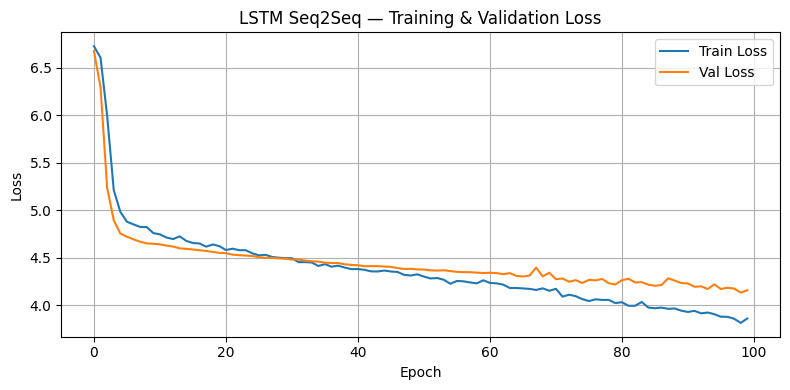

In [239]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses,  label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("LSTM Seq2Seq — Training & Validation Loss")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("loss_curve.png")
plt.show()

In [240]:
for i in range(10):
    q   = test_df["question"].iloc[i]
    c   = test_df["context"].iloc[i]
    gt  = test_df["answer"].iloc[i]
    pred = predict_answer(model1,q, c)
    print(f"Q:    {q}")
    print(f"Pred: {pred}")
    print(f"GT:   {gt}")
    print("---")

Q:    ما الذي كشف عن قدرة أورسون ويلز على التأثير في الجمهور قبل دخوله السينما؟
Pred: في من إلى عن ا ما الصوت باستخدام
GT:   تقديم بث إذاعي تسبب في ذعر جماهيري واسع
---
Q:    كيف كانت طبيعة الإنتاج السينمائي في هوليوود قبل ظهور Citizen Kane؟
Pred: في ما الأسلوب ا مثل سعيدة السينمائي قبل
GT:   كانت تعتمد على أنماط تقليدية ونهايات متوقعة
---
Q:    ما التغيير الأساسي الذي قدمه Citizen Kane في طريقة سرد القصة؟
Pred: في من إلى عن ا ما غير بشكل
GT:   استخدام سرد غير خطي يبدأ من النهاية
---
Q:    كيف ساهم تعدد وجهات النظر في تشكيل صورة شخصية كين؟
Pred: في من إلى ا كين بل الأسلوب شخصية
GT:   عرض الشخصية من زوايا مختلفة ومتضاربة
---
Q:    ما الهدف من استخدام تقنية Deep Focus في الفيلم؟
Pred: في من أو عن ما التي المشهد بوضوح
GT:   تمكين المشاهد من رؤية جميع عناصر المشهد بوضوح واختيار ما يركز عليه
---
Q:    كيف تم توظيف حركة الكاميرا داخل الفيلم؟
Pred: من كل إلى ا بل أساسي ثابتة حركة
GT:   كوسيلة سرد تنقل المعنى وتدعم القصة
---
Q:    ما العامل الذي أدى إلى ضعف النجاح التجاري للفيلم عند صدوره؟
Pre

In [241]:
def f1_score_tokens(predicted, ground_truth):
    pred_tokens = preprocess(predicted).split()
    gt_tokens   = preprocess(ground_truth).split()

    if not pred_tokens or not gt_tokens:
        return 0.0

    # Count common tokens
    pred_set = set(pred_tokens)
    gt_set   = set(gt_tokens)
    common   = pred_set & gt_set

    if not common:
        return 0.0

    precision = len(common) / len(pred_tokens)
    recall    = len(common) / len(gt_tokens)
    f1        = 2 * precision * recall / (precision + recall)
    return f1

def exact_match(predicted, ground_truth):
    return int(preprocess(predicted).strip() == preprocess(ground_truth).strip())



In [242]:
f1_scores = []
em_scores = []

for i in range(len(test_df)):
    q    = test_df["question"].iloc[i]
    c    = test_df["context"].iloc[i]
    gt   = test_df["answer"].iloc[i]
    pred = predict_answer(model1,q, c)

    f1_scores.append(f1_score_tokens(pred, gt))
    em_scores.append(exact_match(pred, gt))

print(f"Exact Match : {sum(em_scores)/len(em_scores)*100:.1f}%")
print(f"F1 Score    : {sum(f1_scores)/len(f1_scores)*100:.1f}%")

Exact Match : 0.0%
F1 Score    : 38.3%


In [243]:
def predict_answer_ordered(model,question, context, max_len=8):
    model.eval()
    inp = preprocess(question) + " SEP " + preprocess(context)
    enc = encode(inp, MAX_INPUT_LEN)
    src = torch.tensor(enc, dtype=torch.long).unsqueeze(0).to(DEVICE)

    stopwords = {'في','من','على','ما','هو','هي','كان','كانت','إلى',
                 'عن','مع','أن','لا','هذا','هذه','التي','الذي','أو',
                 'لم','يكن','ولا','ا','بل','ثم','قد','أي','كل'}

    allowed = set(enc) - {word2idx["<PAD>"], word2idx["<SOS>"],
                          word2idx.get("<UNK>", 1)}

    with torch.no_grad():
        hidden, cell = model.encoder(src)

    dec_input = torch.tensor([word2idx["<SOS>"]], dtype=torch.long).to(DEVICE)
    token_scores = {}
    seen = set()

    for step in range(max_len):
        with torch.no_grad():
            out, hidden, cell = model.decoder(dec_input, hidden, cell)

        mask = torch.full(out.shape, -float('inf')).to(DEVICE)
        for idx in allowed:
            if idx not in seen:
                mask[0][idx] = out[0][idx]
        if step == 0:
            mask[0][word2idx["<EOS>"]] = -float('inf')

        top = mask.argmax(1).item()
        if top == word2idx["<EOS>"]:
            break

        word = idx2word.get(top, "")
        if word and word not in stopwords:
            token_scores[word] = out[0][top].item()

        seen.add(top)
        dec_input = torch.tensor([top], dtype=torch.long).to(DEVICE)

    # Reorder by position in context
    ctx_tokens = preprocess(context).split()
    top_words  = sorted(token_scores.items(),
                        key=lambda x: x[1], reverse=True)[:5]
    top_set    = {w for w, _ in top_words}

    ordered = [w for w in ctx_tokens if w in top_set]

    # Deduplicate while preserving order
    seen_out = set()
    result   = []
    for w in ordered:
        if w not in seen_out:
            result.append(w)
            seen_out.add(w)

    return " ".join(result[:5]) if result else " ".join([w for w,_ in top_words[:3]])

In [244]:
for i in range(10):
    q   = test_df["question"].iloc[i]
    c   = test_df["context"].iloc[i]
    gt  = test_df["answer"].iloc[i]
    pred = predict_answer_ordered(model1,q, c)
    print(f"Q:    {q}")
    print(f"Pred: {pred}")
    print(f"GT:   {gt}")
    print("---")

Q:    ما الذي كشف عن قدرة أورسون ويلز على التأثير في الجمهور قبل دخوله السينما؟
Pred: باستخدام الصوت
GT:   تقديم بث إذاعي تسبب في ذعر جماهيري واسع
---
Q:    كيف كانت طبيعة الإنتاج السينمائي في هوليوود قبل ظهور Citizen Kane؟
Pred: مثل سعيدة الأسلوب
GT:   كانت تعتمد على أنماط تقليدية ونهايات متوقعة
---
Q:    ما التغيير الأساسي الذي قدمه Citizen Kane في طريقة سرد القصة؟
Pred: غير بشكل
GT:   استخدام سرد غير خطي يبدأ من النهاية
---
Q:    كيف ساهم تعدد وجهات النظر في تشكيل صورة شخصية كين؟
Pred: كين شخصية الأسلوب
GT:   عرض الشخصية من زوايا مختلفة ومتضاربة
---
Q:    ما الهدف من استخدام تقنية Deep Focus في الفيلم؟
Pred: المشهد بوضوح
GT:   تمكين المشاهد من رؤية جميع عناصر المشهد بوضوح واختيار ما يركز عليه
---
Q:    كيف تم توظيف حركة الكاميرا داخل الفيلم؟
Pred: ثابتة حركة أساسي
GT:   كوسيلة سرد تنقل المعنى وتدعم القصة
---
Q:    ما العامل الذي أدى إلى ضعف النجاح التجاري للفيلم عند صدوره؟
Pred: ويليام هيرست التغطية بين الجمهور
GT:   الضغط الإعلامي والخوف من نفوذ هيرست
---
Q:    ماذا ترمز كلمة Roseb

In [245]:
f1_scores = []
em_scores = []

for i in range(len(test_df)):
    q    = test_df["question"].iloc[i]
    c    = test_df["context"].iloc[i]
    gt   = test_df["answer"].iloc[i]
    pred = predict_answer_ordered(model1,q, c)

    f1_scores.append(f1_score_tokens(pred, gt))
    em_scores.append(exact_match(pred, gt))

print(f"Exact Match : {sum(em_scores)/len(em_scores)*100:.1f}%")
print(f"F1 Score    : {sum(f1_scores)/len(f1_scores)*100:.1f}%")

Exact Match : 1.4%
F1 Score    : 41.3%


Experiment 2

In [246]:
missing = []
for _, row in train_df.iterrows():
    for word in preprocess(row["answer"]).split():
        if word not in word2idx:
            missing.append(word)

print(f"Missing answer words: {len(missing)}")
print(missing[:10])

Missing answer words: 142
['امتلاك', 'وفرض', 'تحولوا', 'هجوم', 'ذكرى', 'لزوجته', 'زائر', 'سنوي', 'الكمال', 'والانسجام']


In [247]:
# After building word2idx, force important answer words in
important_words = []
for _, row in train_df.iterrows():
    for word in row["answer"].split():
        if word not in word2idx:
            important_words.append(word)

for word in set(important_words):
    if word not in word2idx:
        word2idx[word] = len(word2idx)
        idx2word[word2idx[word]] = word

# Update VOCAB_SIZE after adding all words
VOCAB_SIZE = len(word2idx)

print(f"Added {len(set(important_words))} answer words to vocab")
print(f"New vocab size: {len(word2idx)}")

Added 142 answer words to vocab
New vocab size: 989


In [248]:
# Add answer words first (Cell 27 — keep as is)
# Then immediately rebuild loaders:

train_dataset2 = QADataset(train_df)
test_dataset2  = QADataset(test_df)

train_loader = DataLoader(train_dataset2, batch_size=16, shuffle=True,  collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset2,  batch_size=16, shuffle=False, collate_fn=collate_fn)

print("Loaders rebuilt with new vocab size:", VOCAB_SIZE)

Loaders rebuilt with new vocab size: 989


In [249]:
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMBED_DIM  = 64    # was 256 — too big
HIDDEN_DIM = 128   # was 512 — too big
N_LAYERS   = 2
DROPOUT    = 0.5   # increase dropout to fight overfitting

# 3. More epochs with early stopping
N_EPOCHS = 100

# 4. Early stopping
best_val  = float('inf')
patience  = 0
PATIENCE  =  12
teacher_forcing_ratio = 0.5

encoder = Encoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
decoder = Decoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
model2   = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

optimizer = torch.optim.Adam(model2.parameters(), lr=5e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=0)  # ignore <PAD>

train_losses2, test_losses2 = [], []

for epoch in range(N_EPOCHS):
  # decay teacher forcing each epoch
    tf_ratio = max(0.1, teacher_forcing_ratio - (epoch * 0.03))

    # --- Train ---
    model2.train()
    epoch_loss = 0
    for src, trg in train_loader:
        src, trg = src.to(DEVICE), trg.to(DEVICE)
        optimizer.zero_grad()
        output = model2(src, trg, teacher_forcing_ratio=tf_ratio)
        output = output[:, 1:, :].reshape(-1, VOCAB_SIZE)
        target = trg[:, 1:].reshape(-1)
        loss   = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model2.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    train_losses2.append(epoch_loss / len(train_loader))

    # --- Eval ---
    model2.eval()
    val_loss = 0
    with torch.no_grad():
        for src, trg in test_loader:
            src, trg = src.to(DEVICE), trg.to(DEVICE)
            output = model2(src, trg, teacher_forcing_ratio=0)
            output = output[:, 1:, :].reshape(-1, VOCAB_SIZE)
            target = trg[:, 1:].reshape(-1)
            val_loss += criterion(output, target).item()
    test_losses2.append(val_loss / len(test_loader))

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_losses2[-1]:.4f} | Val Loss: {test_losses2[-1]:.4f}")

    if test_losses[-1] < best_val:
        best_val = test_losses[-1]
        patience = 0
        torch.save(model1.state_dict(), "best_model1.pt")
    else:
        patience += 1
        if patience >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1} | Best val loss: {best_val:.4f}")
            break

Epoch 01 | Train Loss: 6.8858 | Val Loss: 6.8655
Epoch 02 | Train Loss: 6.8088 | Val Loss: 6.6508
Epoch 03 | Train Loss: 6.4550 | Val Loss: 6.0745
Epoch 04 | Train Loss: 5.8721 | Val Loss: 6.0469
Epoch 05 | Train Loss: 5.7022 | Val Loss: 5.9947
Epoch 06 | Train Loss: 5.6088 | Val Loss: 6.0273
Epoch 07 | Train Loss: 5.5572 | Val Loss: 6.0098
Epoch 08 | Train Loss: 5.5135 | Val Loss: 6.0279
Epoch 09 | Train Loss: 5.4786 | Val Loss: 6.0372
Epoch 10 | Train Loss: 5.4441 | Val Loss: 6.0426
Epoch 11 | Train Loss: 5.3921 | Val Loss: 6.0412
Epoch 12 | Train Loss: 5.3801 | Val Loss: 6.0463
Epoch 13 | Train Loss: 5.3398 | Val Loss: 6.0507
Early stopping at epoch 13 | Best val loss: 4.1572


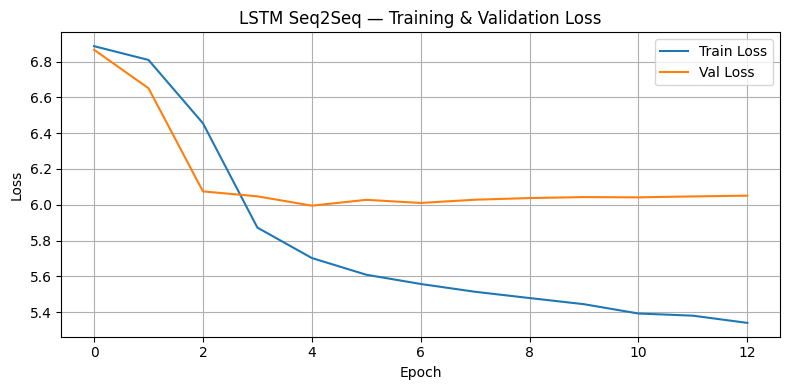

In [250]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses2, label="Train Loss")
plt.plot(test_losses2,  label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("LSTM Seq2Seq — Training & Validation Loss")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("loss_curve.png")
plt.show()

In [251]:
for i in range(10):
    q   = test_df["question"].iloc[i]
    c   = test_df["context"].iloc[i]
    gt  = test_df["answer"].iloc[i]
    pred = predict_answer_ordered(model2,q, c)
    print(f"Q:    {q}")
    print(f"Pred: {pred}")
    print(f"GT:   {gt}")
    print("---")

Q:    ما الذي كشف عن قدرة أورسون ويلز على التأثير في الجمهور قبل دخوله السينما؟
Pred: باستخدام
GT:   تقديم بث إذاعي تسبب في ذعر جماهيري واسع
---
Q:    كيف كانت طبيعة الإنتاج السينمائي في هوليوود قبل ظهور Citizen Kane؟
Pred: مثل سعيدة الأسلوب
GT:   كانت تعتمد على أنماط تقليدية ونهايات متوقعة
---
Q:    ما التغيير الأساسي الذي قدمه Citizen Kane في طريقة سرد القصة؟
Pred: غير بشكل
GT:   استخدام سرد غير خطي يبدأ من النهاية
---
Q:    كيف ساهم تعدد وجهات النظر في تشكيل صورة شخصية كين؟
Pred: كين الأسلوب
GT:   عرض الشخصية من زوايا مختلفة ومتضاربة
---
Q:    ما الهدف من استخدام تقنية Deep Focus في الفيلم؟
Pred: المشهد الأسلوب
GT:   تمكين المشاهد من رؤية جميع عناصر المشهد بوضوح واختيار ما يركز عليه
---
Q:    كيف تم توظيف حركة الكاميرا داخل الفيلم؟
Pred: حركة أساسي
GT:   كوسيلة سرد تنقل المعنى وتدعم القصة
---
Q:    ما العامل الذي أدى إلى ضعف النجاح التجاري للفيلم عند صدوره؟
Pred: هيرست التغطية بين الجمهور
GT:   الضغط الإعلامي والخوف من نفوذ هيرست
---
Q:    ماذا ترمز كلمة Rosebud في التفسير النهائي ل

In [252]:
f1_scores = []
em_scores = []

for i in range(len(test_df)):
    q    = test_df["question"].iloc[i]
    c    = test_df["context"].iloc[i]
    gt   = test_df["answer"].iloc[i]
    pred = predict_answer_ordered(model2,q, c)

    f1_scores.append(f1_score_tokens(pred, gt))
    em_scores.append(exact_match(pred, gt))

print(f"Exact Match : {sum(em_scores)/len(em_scores)*100:.1f}%")
print(f"F1 Score    : {sum(f1_scores)/len(f1_scores)*100:.1f}%")

Exact Match : 1.4%
F1 Score    : 40.6%
